# Step 2: Multi-Timeframe Features

## 🎯 Objective:
Menambahkan **multi-timeframe features** untuk capture market dynamics di berbagai time horizons.

## 📊 Features Progression:

### **Step 1 (Baseline - 3 features):**
- `Vol_20`: 20-day volatility
- `Mom_20`: 20-day momentum
- `Mom_50`: 50-day momentum

### **Step 2 (NEW - 6 features total):**
- ✅ All Step 1 features
- ➕ `Vol_5`: 5-day volatility (short-term)
- ➕ `Mom_5`: 5-day momentum (short-term)
- ➕ `Mom_10`: 10-day momentum (medium-term)

## 💡 Rationale:
Multi-timeframe analysis captures:
- **Short-term (5d)**: Immediate market reactions
- **Medium-term (10-20d)**: Swing trading patterns
- **Long-term (50d)**: Macro trend direction

## 🎓 Models:
1. **Random Forest** (ensemble, non-linear)
2. **Logistic Regression** (linear, interpretable)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")
print("\n📦 Step 2: Multi-Timeframe Features")
print("  Adding: Vol_5, Mom_5, Mom_10")
print("  Total features: 6")

✅ Libraries loaded successfully!

📦 Step 2: Multi-Timeframe Features
  Adding: Vol_5, Mom_5, Mom_10
  Total features: 6


## 1. Data Loading

In [2]:
# Load data
file_path = 'dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)

print(f"📊 Dataset loaded: {len(data)} rows")
print(f"📅 Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"💰 Assets: {list(data.columns)}")

📊 Dataset loaded: 990 rows
📅 Date range: 2023-04-17 to 2025-12-31
💰 Assets: ['AAVE-USD', 'ADA-USD', 'BCH-USD', 'BNB-USD', 'BTC-USD', 'CRO-USD', 'DAI-USD', 'DASH-USD', 'DOGE-USD', 'ETH-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'MKR-USD', 'OKB-USD', 'PEPE24478-USD', 'SHIB-USD', 'SOL-USD', 'UNI7083-USD', 'USDC-USD', 'USDT-USD', 'XMR-USD', 'XRP-USD', 'ZEC-USD']


## 2. Feature Engineering (6 Features)

In [3]:
# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Create features
features = pd.DataFrame(index=returns.index)

# === STEP 1 FEATURES (Baseline) ===
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# === STEP 2 FEATURES (NEW - Multi-Timeframe) ===
# Short-term (5 days)
features['Vol_5'] = market_return.rolling(window=5).std()
features['Mom_5'] = market_return.rolling(window=5).mean()

# Medium-term (10 days)
features['Mom_10'] = market_return.rolling(window=10).mean()

# Target
features['Target'] = (market_return.shift(-1) > 0).astype(int)

# Drop NaN
features = features.dropna()

print("\n✅ Features created:")
print(f"  Total features: {len(features.columns) - 1}")
print(f"\n📊 Feature List:")
print("  Step 1 (Baseline):")
print("    - Vol_20, Mom_20, Mom_50")
print("  Step 2 (NEW):")
print("    - Vol_5, Mom_5, Mom_10")

print("\n📊 Feature Statistics:")
print(features.describe())

print("\n📊 Target Distribution:")
target_dist = features['Target'].value_counts()
print(f"  Bearish (0): {target_dist[0]} ({target_dist[0]/len(features)*100:.1f}%)")
print(f"  Bullish (1): {target_dist[1]} ({target_dist[1]/len(features)*100:.1f}%)")


✅ Features created:
  Total features: 6

📊 Feature List:
  Step 1 (Baseline):
    - Vol_20, Mom_20, Mom_50
  Step 2 (NEW):
    - Vol_5, Mom_5, Mom_10

📊 Feature Statistics:
           Vol_20      Mom_20      Mom_50       Vol_5       Mom_5      Mom_10  \
count  927.000000  927.000000  927.000000  927.000000  927.000000  927.000000   
mean     0.026746    0.001915    0.001912    0.024753    0.001982    0.001968   
std      0.008193    0.006304    0.004056    0.013076    0.012378    0.008717   
min      0.010481   -0.014521   -0.006813    0.004034   -0.045429   -0.021287   
25%      0.020885   -0.002194   -0.001175    0.015186   -0.004624   -0.003559   
50%      0.026325    0.001098    0.001255    0.022363    0.001536    0.001332   
75%      0.031759    0.005080    0.004360    0.031267    0.009100    0.006922   
max      0.049392    0.025813    0.013732    0.083167    0.047908    0.038539   

           Target  
count  927.000000  
mean     0.548004  
std      0.497959  
min      0.00000

## 3. Train/Test Split

In [4]:
# Feature columns (6 features)
feature_cols = ['Vol_20', 'Mom_20', 'Mom_50', 'Vol_5', 'Mom_5', 'Mom_10']

# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train = features.loc[train_mask, feature_cols]
y_train = features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, feature_cols]
y_test = features.loc[test_mask, 'Target']

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\n📚 Training Set: {len(X_train)} samples")
print(f"   Period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"   Bearish: {(y_train==0).sum()} | Bullish: {(y_train==1).sum()}")

print(f"\n🧪 Testing Set: {len(X_test)} samples")
print(f"   Period: {X_test.index[0].date()} to {X_test.index[-1].date()}")
print(f"   Bearish: {(y_test==0).sum()} | Bullish: {(y_test==1).sum()}")
print("=" * 60)

TRAIN/TEST SPLIT

📚 Training Set: 562 samples
   Period: 2023-06-19 to 2024-12-31
   Bearish: 250 | Bullish: 312

🧪 Testing Set: 365 samples
   Period: 2025-01-01 to 2025-12-31
   Bearish: 169 | Bullish: 196


## 4. Model Training

In [5]:
print("🔄 Training models with 6 features...\n")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_split=10,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
print("✅ Random Forest trained")

# Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)
lr_test_proba = lr_model.predict_proba(X_test)[:, 1]
print("✅ Logistic Regression trained")

🔄 Training models with 6 features...

✅ Random Forest trained
✅ Logistic Regression trained


## 5. Performance Comparison

In [6]:
def calculate_metrics(y_true, y_pred, model_name, dataset_name):
    """Calculate performance metrics"""
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

# Calculate metrics
results = []
results.append(calculate_metrics(y_train, rf_train_pred, 'Random Forest', 'Training'))
results.append(calculate_metrics(y_test, rf_test_pred, 'Random Forest', 'Testing'))
results.append(calculate_metrics(y_train, lr_train_pred, 'Logistic Regression', 'Training'))
results.append(calculate_metrics(y_test, lr_test_pred, 'Logistic Regression', 'Testing'))

results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("STEP 2: PERFORMANCE WITH 6 FEATURES")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)


STEP 2: PERFORMANCE WITH 6 FEATURES
              Model  Dataset  Accuracy  Precision   Recall  F1-Score
      Random Forest Training  0.976868   0.968652 0.990385  0.979398
      Random Forest  Testing  0.460274   0.497976 0.627551  0.555305
Logistic Regression Training  0.555160   0.555160 1.000000  0.713959
Logistic Regression  Testing  0.536986   0.536986 1.000000  0.698752


## 6. Comparison with Step 1 (Baseline)

In [7]:
# Train models with Step 1 features only (for comparison)
step1_features = ['Vol_20', 'Mom_20', 'Mom_50']

X_train_step1 = features.loc[train_mask, step1_features]
X_test_step1 = features.loc[test_mask, step1_features]

# Random Forest - Step 1
rf_step1 = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10, n_jobs=-1)
rf_step1.fit(X_train_step1, y_train)
rf_step1_pred = rf_step1.predict(X_test_step1)

# Logistic Regression - Step 1
lr_step1 = LogisticRegression(random_state=42, max_iter=1000)
lr_step1.fit(X_train_step1, y_train)
lr_step1_pred = lr_step1.predict(X_test_step1)

# Create comparison table
comparison_data = [
    {
        'Step': 'Step 1 (3 features)',
        'Features': 'Vol_20, Mom_20, Mom_50',
        'RF_Accuracy': accuracy_score(y_test, rf_step1_pred),
        'LR_Accuracy': accuracy_score(y_test, lr_step1_pred)
    },
    {
        'Step': 'Step 2 (6 features)',
        'Features': '+ Vol_5, Mom_5, Mom_10',
        'RF_Accuracy': accuracy_score(y_test, rf_test_pred),
        'LR_Accuracy': accuracy_score(y_test, lr_test_pred)
    }
]

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("STEP 1 vs STEP 2 COMPARISON (Test Set)")
print("="*70)
print(comparison_df.to_string(index=False))

# Calculate improvement
rf_improvement = (comparison_df.iloc[1]['RF_Accuracy'] - comparison_df.iloc[0]['RF_Accuracy']) * 100
lr_improvement = (comparison_df.iloc[1]['LR_Accuracy'] - comparison_df.iloc[0]['LR_Accuracy']) * 100

print("\n📈 IMPROVEMENT:")
print(f"  Random Forest: {rf_improvement:+.2f}% {'✅' if rf_improvement > 0 else '⚠️'}")
print(f"  Logistic Regression: {lr_improvement:+.2f}% {'✅' if lr_improvement > 0 else '⚠️'}")
print("="*70)


STEP 1 vs STEP 2 COMPARISON (Test Set)
               Step               Features  RF_Accuracy  LR_Accuracy
Step 1 (3 features) Vol_20, Mom_20, Mom_50     0.520548     0.536986
Step 2 (6 features) + Vol_5, Mom_5, Mom_10     0.460274     0.536986

📈 IMPROVEMENT:
  Random Forest: -6.03% ⚠️
  Logistic Regression: +0.00% ⚠️


## 7. Confusion Matrix Comparison

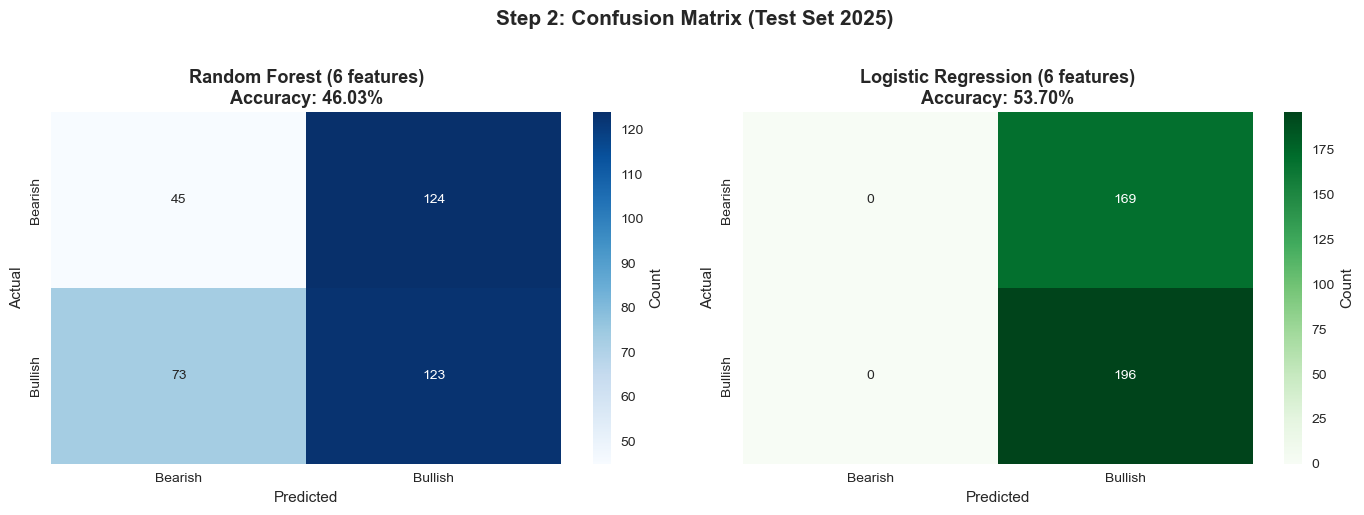

In [8]:
# Confusion matrices
cm_rf = confusion_matrix(y_test, rf_test_pred)
cm_lr = confusion_matrix(y_test, lr_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[0], cbar_kws={'label': 'Count'})
rf_acc = accuracy_score(y_test, rf_test_pred)
axes[0].set_title(f'Random Forest (6 features)\nAccuracy: {rf_acc:.2%}', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[1], cbar_kws={'label': 'Count'})
lr_acc = accuracy_score(y_test, lr_test_pred)
axes[1].set_title(f'Logistic Regression (6 features)\nAccuracy: {lr_acc:.2%}', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.suptitle('Step 2: Confusion Matrix (Test Set 2025)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

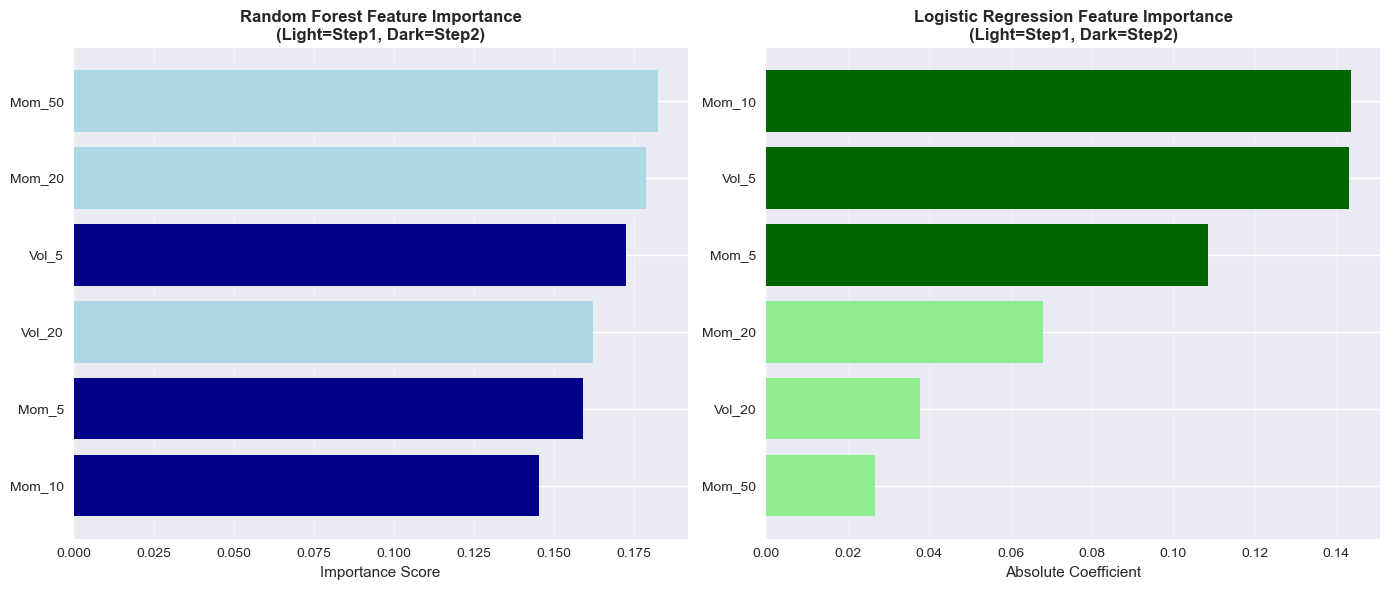


📊 Feature Importance Rankings:

Random Forest:
Feature  Importance
 Mom_50    0.182507
 Mom_20    0.178685
  Vol_5    0.172504
 Vol_20    0.162138
  Mom_5    0.158962
 Mom_10    0.145203

Logistic Regression (with signs):
  [Step 1] Vol_20: -0.0378
  [Step 1] Mom_20: +0.0680
  [Step 1] Mom_50: -0.0267
  [Step 2] Vol_5: +0.1431
  [Step 2] Mom_5: +0.1084
  [Step 2] Mom_10: +0.1436


In [9]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

colors_rf = ['lightblue' if 'Vol_20' in f or 'Mom_20' in f or 'Mom_50' in f 
             else 'darkblue' for f in rf_importance['Feature']]
axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color=colors_rf)
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Random Forest Feature Importance\n(Light=Step1, Dark=Step2)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Logistic Regression
lr_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=True)

colors_lr = ['lightgreen' if 'Vol_20' in f or 'Mom_20' in f or 'Mom_50' in f 
             else 'darkgreen' for f in lr_importance['Feature']]
axes[1].barh(lr_importance['Feature'], lr_importance['Coefficient'], color=colors_lr)
axes[1].set_xlabel('Absolute Coefficient', fontsize=11)
axes[1].set_title('Logistic Regression Feature Importance\n(Light=Step1, Dark=Step2)', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Rankings:")
print("\nRandom Forest:")
print(rf_importance.sort_values('Importance', ascending=False).to_string(index=False))
print("\nLogistic Regression (with signs):")
for feature, coef in zip(feature_cols, lr_model.coef_[0]):
    step = "[Step 1]" if feature in step1_features else "[Step 2]"
    print(f"  {step} {feature}: {coef:+.4f}")

## 9. Actual vs Predicted Visualization

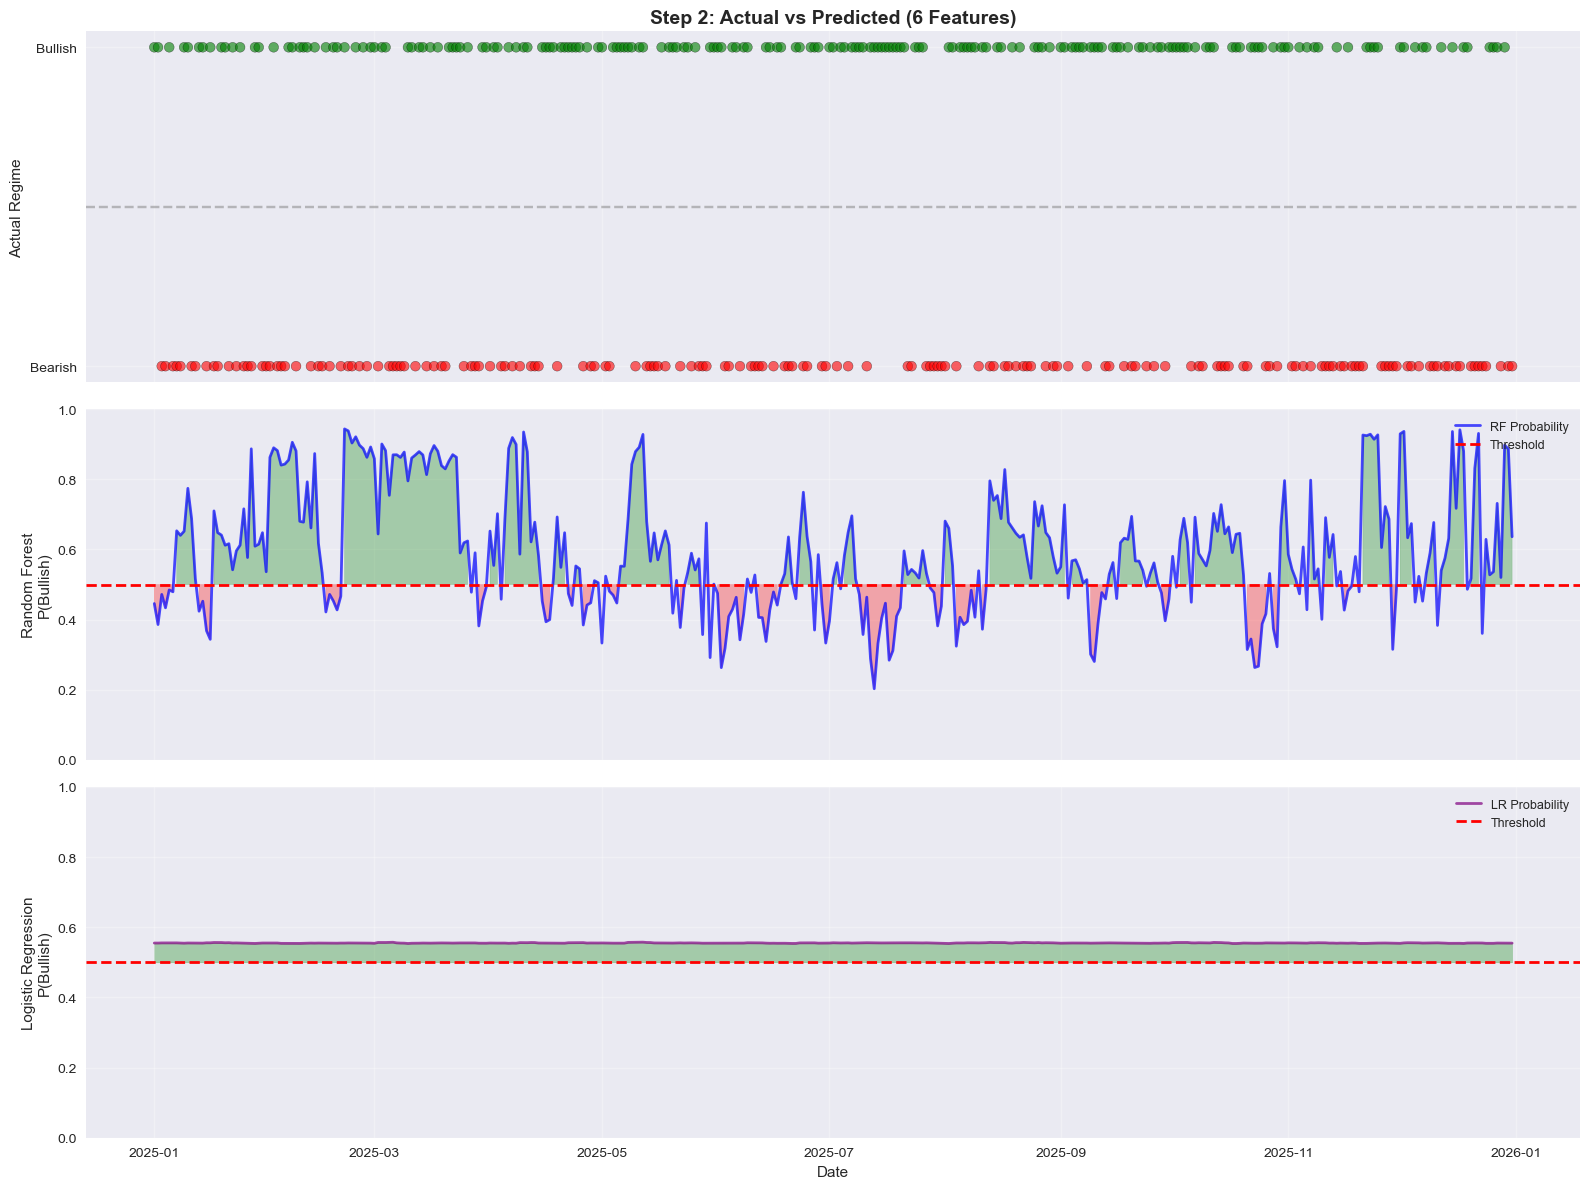

In [10]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Actual': y_test,
    'RF_Pred': rf_test_pred,
    'LR_Pred': lr_test_pred,
    'RF_Proba': rf_test_proba,
    'LR_Proba': lr_test_proba
}, index=y_test.index)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Actual
colors_actual = ['red' if x == 0 else 'green' for x in comparison['Actual']]
axes[0].scatter(comparison.index, comparison['Actual'], 
                c=colors_actual, alpha=0.6, s=50, edgecolors='black')
axes[0].set_ylabel('Actual Regime', fontsize=11)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Bearish', 'Bullish'])
axes[0].set_title('Step 2: Actual vs Predicted (6 Features)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Random Forest
axes[1].plot(comparison.index, comparison['RF_Proba'], 
             linewidth=2, color='blue', alpha=0.7, label='RF Probability')
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].fill_between(comparison.index, 0.5, comparison['RF_Proba'],
                     where=(comparison['RF_Proba'] >= 0.5), 
                     alpha=0.3, color='green')
axes[1].fill_between(comparison.index, comparison['RF_Proba'], 0.5,
                     where=(comparison['RF_Proba'] < 0.5), 
                     alpha=0.3, color='red')
axes[1].set_ylabel('Random Forest\nP(Bullish)', fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

# Logistic Regression
axes[2].plot(comparison.index, comparison['LR_Proba'], 
             linewidth=2, color='purple', alpha=0.7, label='LR Probability')
axes[2].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[2].fill_between(comparison.index, 0.5, comparison['LR_Proba'],
                     where=(comparison['LR_Proba'] >= 0.5), 
                     alpha=0.3, color='green')
axes[2].fill_between(comparison.index, comparison['LR_Proba'], 0.5,
                     where=(comparison['LR_Proba'] < 0.5), 
                     alpha=0.3, color='red')
axes[2].set_ylabel('Logistic Regression\nP(Bullish)', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].set_ylim([0, 1])
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Summary & Next Steps

In [11]:
print("\n" + "="*70)
print("STEP 2: MULTI-TIMEFRAME FEATURES SUMMARY")
print("="*70)

print("\n📊 CONFIGURATION:")
print(f"  Total Features: 6")
print(f"  Step 1: Vol_20, Mom_20, Mom_50")
print(f"  Step 2: Vol_5, Mom_5, Mom_10")

print("\n🏆 PERFORMANCE (Test Set):")
test_results = results_df[results_df['Dataset'] == 'Testing']
print(test_results[['Model', 'Accuracy', 'F1-Score']].to_string(index=False))

print("\n📈 IMPROVEMENT FROM STEP 1:")
print(f"  Random Forest: {rf_improvement:+.2f}%")
print(f"  Logistic Regression: {lr_improvement:+.2f}%")

# Determine best model
rf_test_acc = test_results[test_results['Model'] == 'Random Forest']['Accuracy'].values[0]
lr_test_acc = test_results[test_results['Model'] == 'Logistic Regression']['Accuracy'].values[0]

print("\n🎯 BEST MODEL (Step 2):")
if rf_test_acc > lr_test_acc:
    print(f"  ✅ Random Forest ({rf_test_acc:.2%})")
else:
    print(f"  ✅ Logistic Regression ({lr_test_acc:.2%})")

print("\n💡 INSIGHTS:")
if rf_improvement > 0 or lr_improvement > 0:
    print("  ✅ Multi-timeframe features improve performance")
    print("  ✅ Different time horizons capture complementary signals")
else:
    print("  ⚠️ Multi-timeframe features show limited improvement")
    print("  💡 May need feature selection or regularization")

print("\n📈 NEXT STEPS:")
print("  Step 3: Add statistical features (Skewness, Kurtosis)")
print("  Step 4: Add cross-asset features (Correlation, Dispersion)")
print("  Step 5: Final model selection & optimization")

print("\n" + "="*70)


STEP 2: MULTI-TIMEFRAME FEATURES SUMMARY

📊 CONFIGURATION:
  Total Features: 6
  Step 1: Vol_20, Mom_20, Mom_50
  Step 2: Vol_5, Mom_5, Mom_10

🏆 PERFORMANCE (Test Set):
              Model  Accuracy  F1-Score
      Random Forest  0.460274  0.555305
Logistic Regression  0.536986  0.698752

📈 IMPROVEMENT FROM STEP 1:
  Random Forest: -6.03%
  Logistic Regression: +0.00%

🎯 BEST MODEL (Step 2):
  ✅ Logistic Regression (53.70%)

💡 INSIGHTS:
  ⚠️ Multi-timeframe features show limited improvement
  💡 May need feature selection or regularization

📈 NEXT STEPS:
  Step 3: Add statistical features (Skewness, Kurtosis)
  Step 4: Add cross-asset features (Correlation, Dispersion)
  Step 5: Final model selection & optimization

